Scrapping Google Apps Review - KAI ACCESS

*INITIAL SETUP*

In [1]:
!pip install google_play_scraper
!pip install textblob
!pip install seaborn


[notice] A new release of pip is available: 25.0.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
from google_play_scraper import app
import pandas as pd
import numpy as np
import sklearn
import requests
import matplotlib.pyplot as plt
import matplotlib.dates as dates
import seaborn as sns
import textblob
from pathlib import Path
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix,classification_report, accuracy_score
import pickle
import re
import time
import datetime
import os
from PIL import Image
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

%matplotlib inline
%config InlineBackend.figure_format='retina'

# Import seaborn styles explicitly
import seaborn as sns
# Apply the seaborn style before creating plots
sns.set_style("whitegrid")  # This line sets the Seaborn style
plt.rcParams["figure.figsize"] = (15,10)

Get Raw Dataset

In [1]:
from google_play_scraper import reviews_all, Sort

kaireview_reviews = reviews_all(
    'com.kai.kaiticketing',
    sleep_milliseconds=0,
    lang='id',
    sort=Sort.NEWEST
)

In [5]:
#Save kai access reviews into dataframe 
df_kai = pd.DataFrame(np.array(kaireview_reviews),columns=['content']) 
df_kai = df_kai.join(pd.DataFrame(df_kai.pop('content').tolist())) 
df_kai.to_csv(r'df_kai_raw', index=False)

Exploratory Data Analysis (EDA)

In [6]:
# Check dataframe
df_kai

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,f8f26d99-a5cd-4a90-bbdd-079c3a87b879,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,untuk top up lama banget tolong dong diperbaik...,1,0,6.13.2,2025-09-21 21:50:19,None,NaT,6.13.2
1,136cf3f1-41c1-41ab-b189-c0129e183671,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,jwuebege,5,0,6.13.2,2025-09-21 21:10:40,None,NaT,6.13.2
2,a3336989-522d-4f46-a876-2c41e0b1dbe6,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,APLIKASI TOLOL. KODE OTP LAMA.BIKIN PASWORD GK...,1,0,None,2025-09-21 20:27:25,None,NaT,None
3,e668591c-99ff-4046-bc11-613bb34f3f10,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,good 👍,5,0,6.13.2,2025-09-21 19:36:01,None,NaT,6.13.2
4,b441ea42-c5cd-4d73-af1d-b1dc57ef729c,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,setiap top up terpotong 3rban lama nunggu 15mn...,4,0,6.13.2,2025-09-21 19:13:17,None,NaT,6.13.2
...,...,...,...,...,...,...,...,...,...,...,...
109177,f83457d0-e803-47f9-bce3-6dbca29120bf,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Good,5,0,1.0.0.1,2014-07-16 11:59:56,None,NaT,1.0.0.1
109178,622fb470-1237-41a0-be5f-43a72d59364d,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Keren,5,0,1.0.0.1,2014-07-16 11:36:16,None,NaT,1.0.0.1
109179,77683699-4e3d-4ece-bf2c-9e956e8c9eb8,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Semoga segera di fix kan gangguan bug di app,5,0,1.0.0.1,2014-07-16 11:29:55,None,NaT,1.0.0.1
109180,8bedf713-ff51-4fcc-815d-39d30d47ccf0,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Sangat membantu,4,0,1.0.0.1,2014-07-16 11:24:14,None,NaT,1.0.0.1


In [7]:
df_kai.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109182 entries, 0 to 109181
Data columns (total 11 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   reviewId              109182 non-null  object        
 1   userName              109182 non-null  object        
 2   userImage             109182 non-null  object        
 3   content               109171 non-null  object        
 4   score                 109182 non-null  int64         
 5   thumbsUpCount         109182 non-null  int64         
 6   reviewCreatedVersion  87919 non-null   object        
 7   at                    109182 non-null  datetime64[ns]
 8   replyContent          12501 non-null   object        
 9   repliedAt             12501 non-null   datetime64[ns]
 10  appVersion            87919 non-null   object        
dtypes: datetime64[ns](2), int64(2), object(7)
memory usage: 9.2+ MB


In [8]:
#We do not need data for column reviewId, userName, userImage so we will show only these column
df_kai.loc[:,["content","score","thumbsUpCount", "reviewCreatedVersion", "at", "replyContent", "repliedAt"]]

,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt
0,untuk top up lama banget tolong dong diperbaik...,1,0,6.13.2,2025-09-21 21:50:19,None,NaT
1,jwuebege,5,0,6.13.2,2025-09-21 21:10:40,None,NaT
2,APLIKASI TOLOL. KODE OTP LAMA.BIKIN PASWORD GK...,1,0,None,2025-09-21 20:27:25,None,NaT
3,good 👍,5,0,6.13.2,2025-09-21 19:36:01,None,NaT
4,setiap top up terpotong 3rban lama nunggu 15mn...,4,0,6.13.2,2025-09-21 19:13:17,None,NaT
...,...,...,...,...,...,...,...
109177,Good,5,0,1.0.0.1,2014-07-16 11:59:56,None,NaT
109178,Keren,5,0,1.0.0.1,2014-07-16 11:36:16,None,NaT
109179,Semoga segera di fix kan gangguan bug di app,5,0,1.0.0.1,2014-07-16 11:29:55,None,NaT
109180,Sangat membantu,4,0,1.0.0.1,2014-07-16 11:24:14,None,NaT


In [9]:
#Check number of reviews scores
df_kai['score'].value_counts()

score
1    50426
5    35350
2     9600
3     7250
4     6556
Name: count, dtype: int64

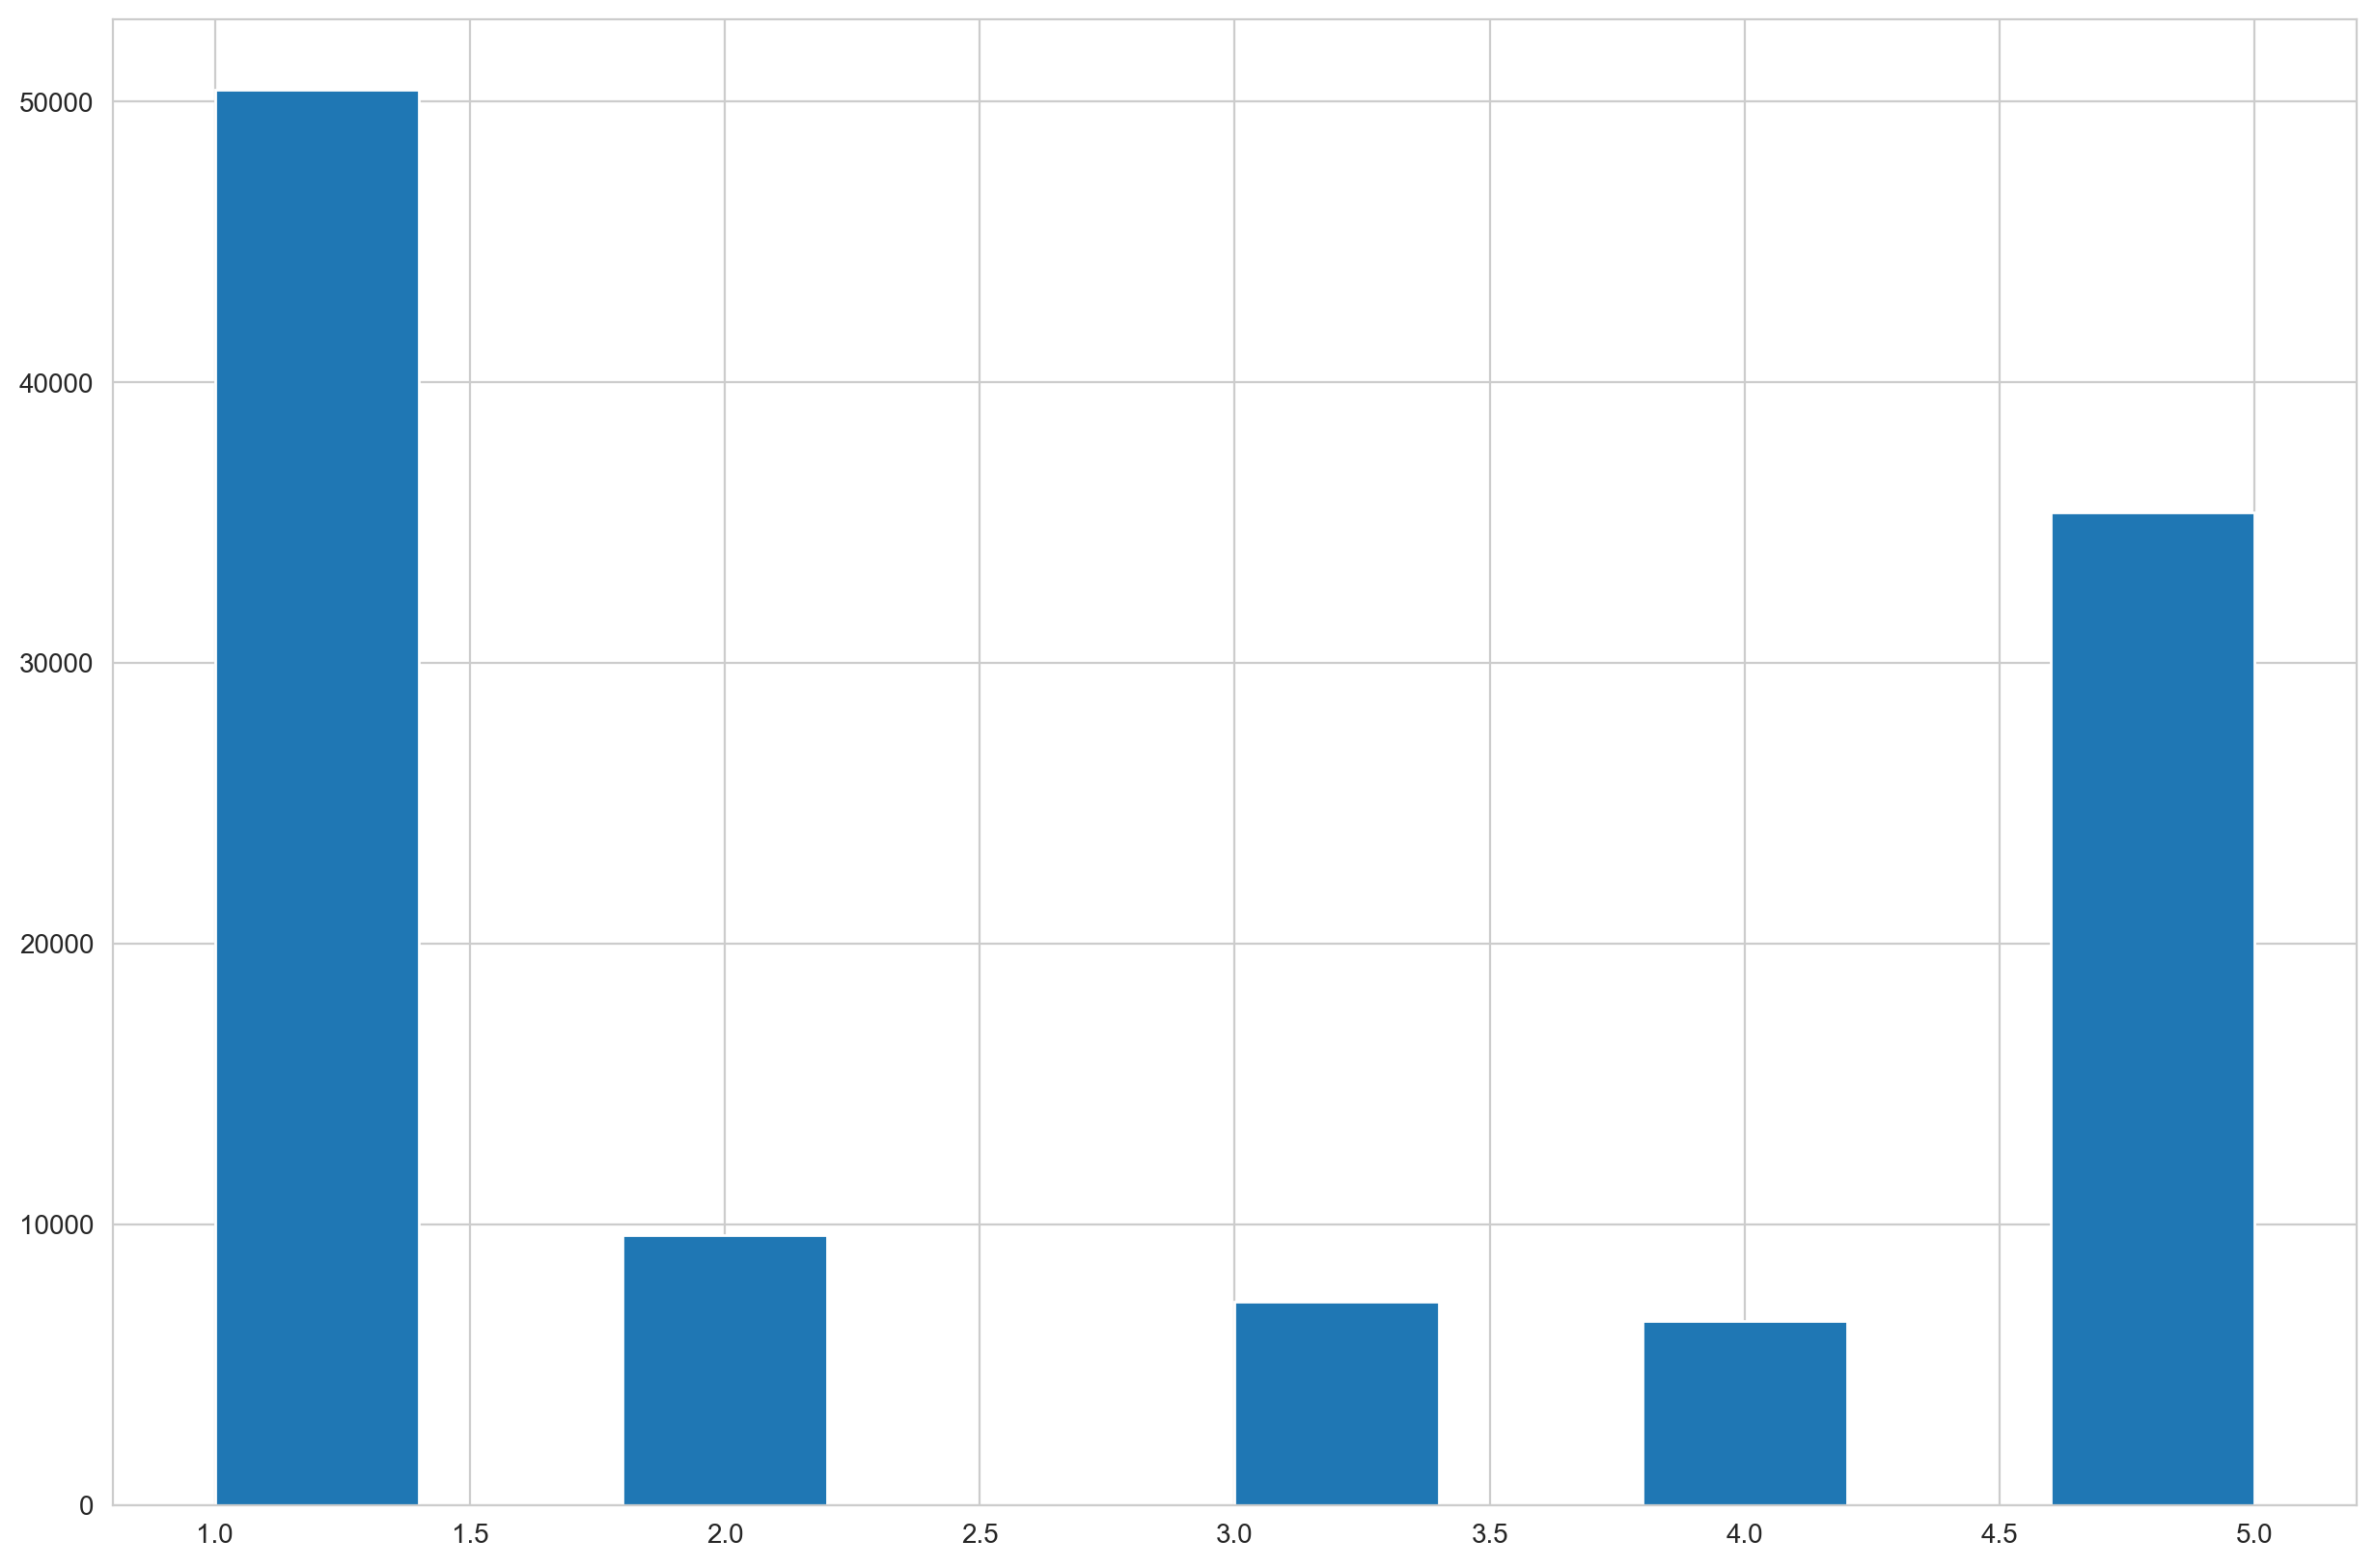

In [10]:
# Score distribution check
plt.hist(df_kai['score'])
plt.show()

TEXT PROSESSING

1. LOWER CASE

In [11]:

# Lower casing
# Change the reviews type to string
df_kai['content'] = df_kai['content'].astype(str)# Before lowercasing
# Before lowercasing
print(df_kai['content'][188])
print(df_kai['content'][1])
print(df_kai['content'][1000])
     

👍
jwuebege
jos gandos mantap


In [14]:
#Lowercase all reviews to see the difference
df_kai['content']= df_kai['content'].apply(lambda x: x.lower())
print(df_kai['content'][188])
print(df_kai['content'][1])
print(df_kai['content'][1000])

👍
jwuebege
jos gandos mantap


TOKENIZATION 

In [15]:
import nltk
from nltk.tokenize import word_tokenize

# pastikan resource punkt udah ada
nltk.download('punkt_tab')

# bikin kolom baru 'tokens' hasil tokenisasi
df_kai['tokens'] = df_kai['content'].apply(word_tokenize)

# cek hasilnya
print(df_kai[['content', 'tokens']].head(10))

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\fajri\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


                                             content  \
0  untuk top up lama banget tolong dong diperbaik...   
1                                           jwuebege   
2  aplikasi tolol. kode otp lama.bikin pasword gk...   
3                                             good 👍   
4  setiap top up terpotong 3rban lama nunggu 15mn...   
5                                      malang jember   
6                                         oke mantap   
7                                    mudah dan cepat   
8  hampir tiap kali mau buka aplikasi mesti di up...   
9  alhamdulillah dengan kai access pp karawang ja...   

                                              tokens  
0  [untuk, top, up, lama, banget, tolong, dong, d...  
1                                         [jwuebege]  
2  [aplikasi, tolol, ., kode, otp, lama.bikin, pa...  
3                                          [good, 👍]  
4  [setiap, top, up, terpotong, 3rban, lama, nung...  
5                                   [malang, jember] 

Before Stop Words Preprocessing

In [16]:
# function to plot most frequent terms
def freq_words(x, terms=30):
    all_words = ' '.join([text for text in x])
    all_words = all_words.split()

    # Import FreqDist from nltk.probability
    from nltk.probability import FreqDist
    fdist = FreqDist(all_words)

    words_df = pd.DataFrame({
        'word': list(fdist.keys()),
        'count': list(fdist.values())
    })

    # selecting top N most frequent words
    d = words_df.nlargest(columns="count", n=terms)

    plt.figure(figsize=(20, 5))
    # Use the 'rainbow' colormap for the bar plot
    ax = sns.barplot(data=d, x="word", y="count", palette="rainbow")
    ax.set(ylabel='Count')

    # Tambahin title
    plt.title(f"Most Frequent Words (Before Stop Words Removal) - Top {terms}")

    plt.show()

C:\Users\fajri\AppData\Local\Temp\ipykernel_7704\2314564518.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=d, x="word", y="count", palette="rainbow")


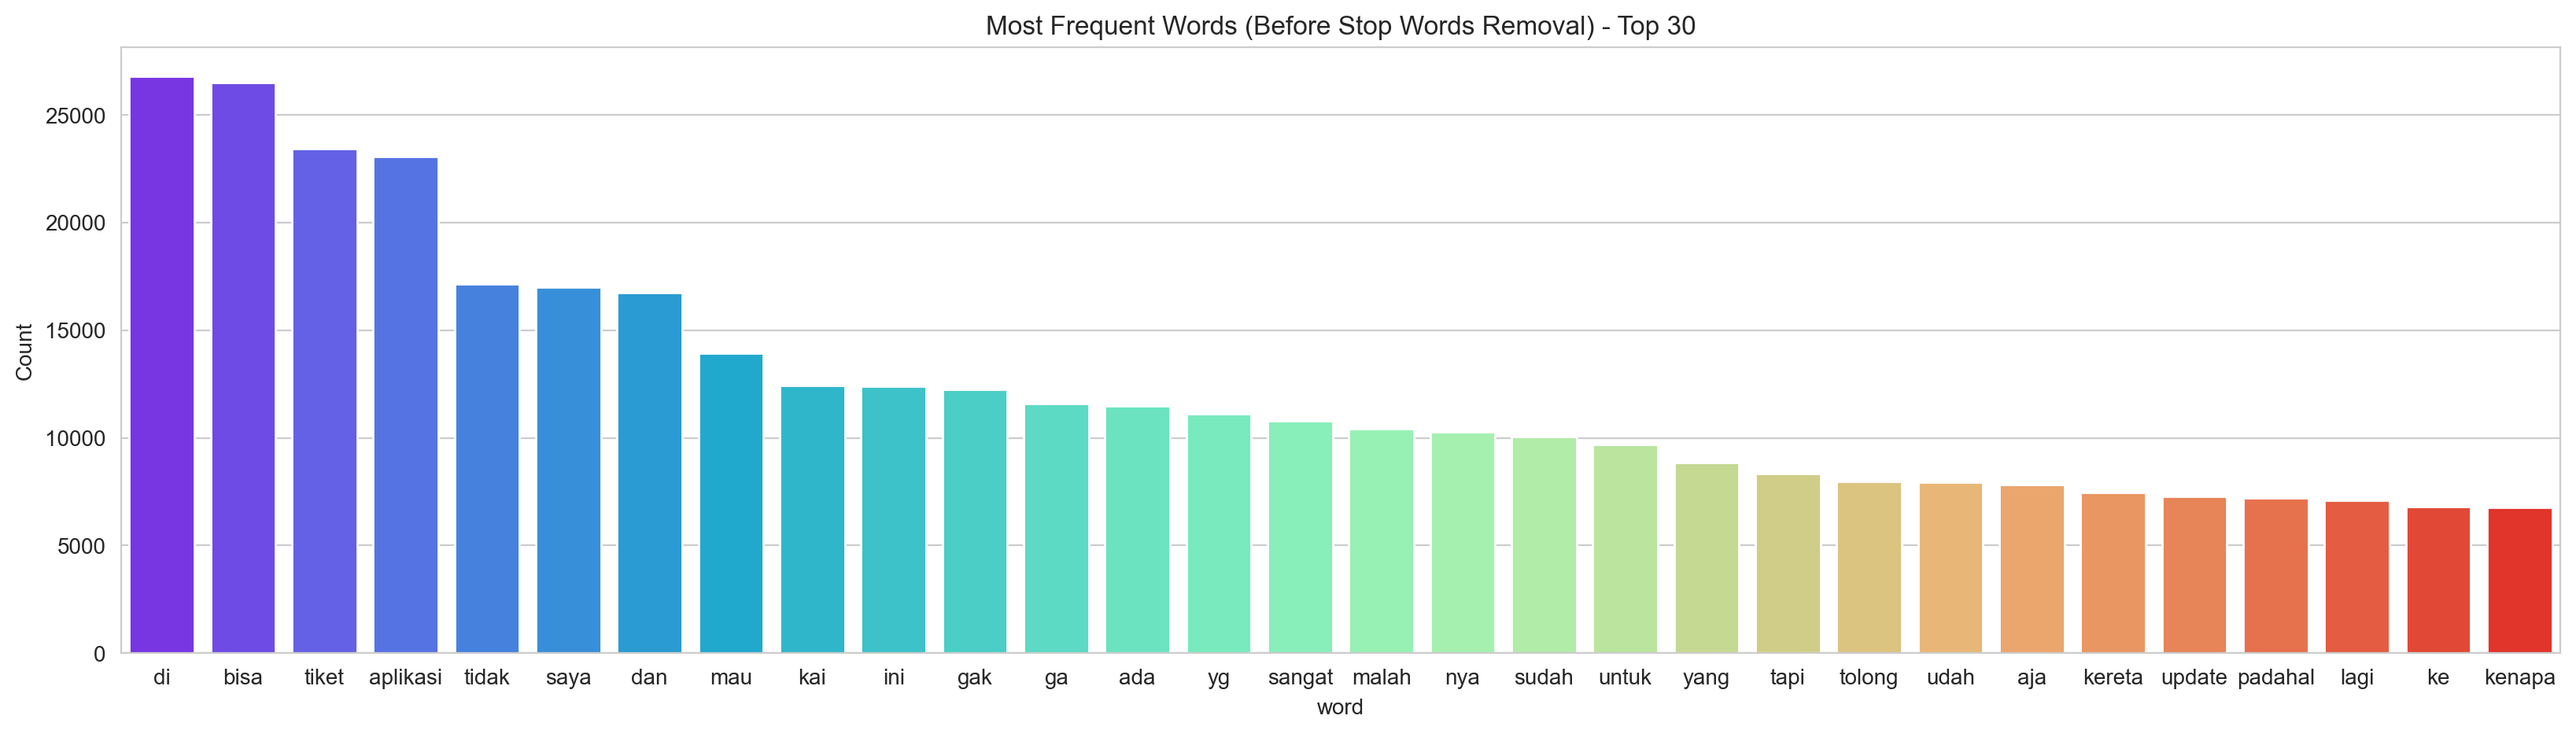

In [17]:
freq_words(df_kai['content'])

Stopwords Removal (Indonesian Stopwords)

In [18]:

import nltk
import matplotlib.pyplot as plt
import pandas as pd
from nltk.corpus import stopwords
from collections import Counter

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\fajri\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [19]:

# Get Indonesian stopwords
indonesian_stopwords = stopwords.words('indonesian')

# Display first 20 stopwords
print(indonesian_stopwords[:20])

['ada', 'adalah', 'adanya', 'adapun', 'agak', 'agaknya', 'agar', 'akan', 'akankah', 'akhir', 'akhiri', 'akhirnya', 'aku', 'akulah', 'amat', 'amatlah', 'anda', 'andalah', 'antar', 'antara']


,Word,Frequency
0,tiket,23443
1,aplikasi,23065
2,kai,12418
3,gak,12256
4,ga,11595
...,...,...
95,no,1514
96,parah,1496
97,suka,1489
98,langsung,1483


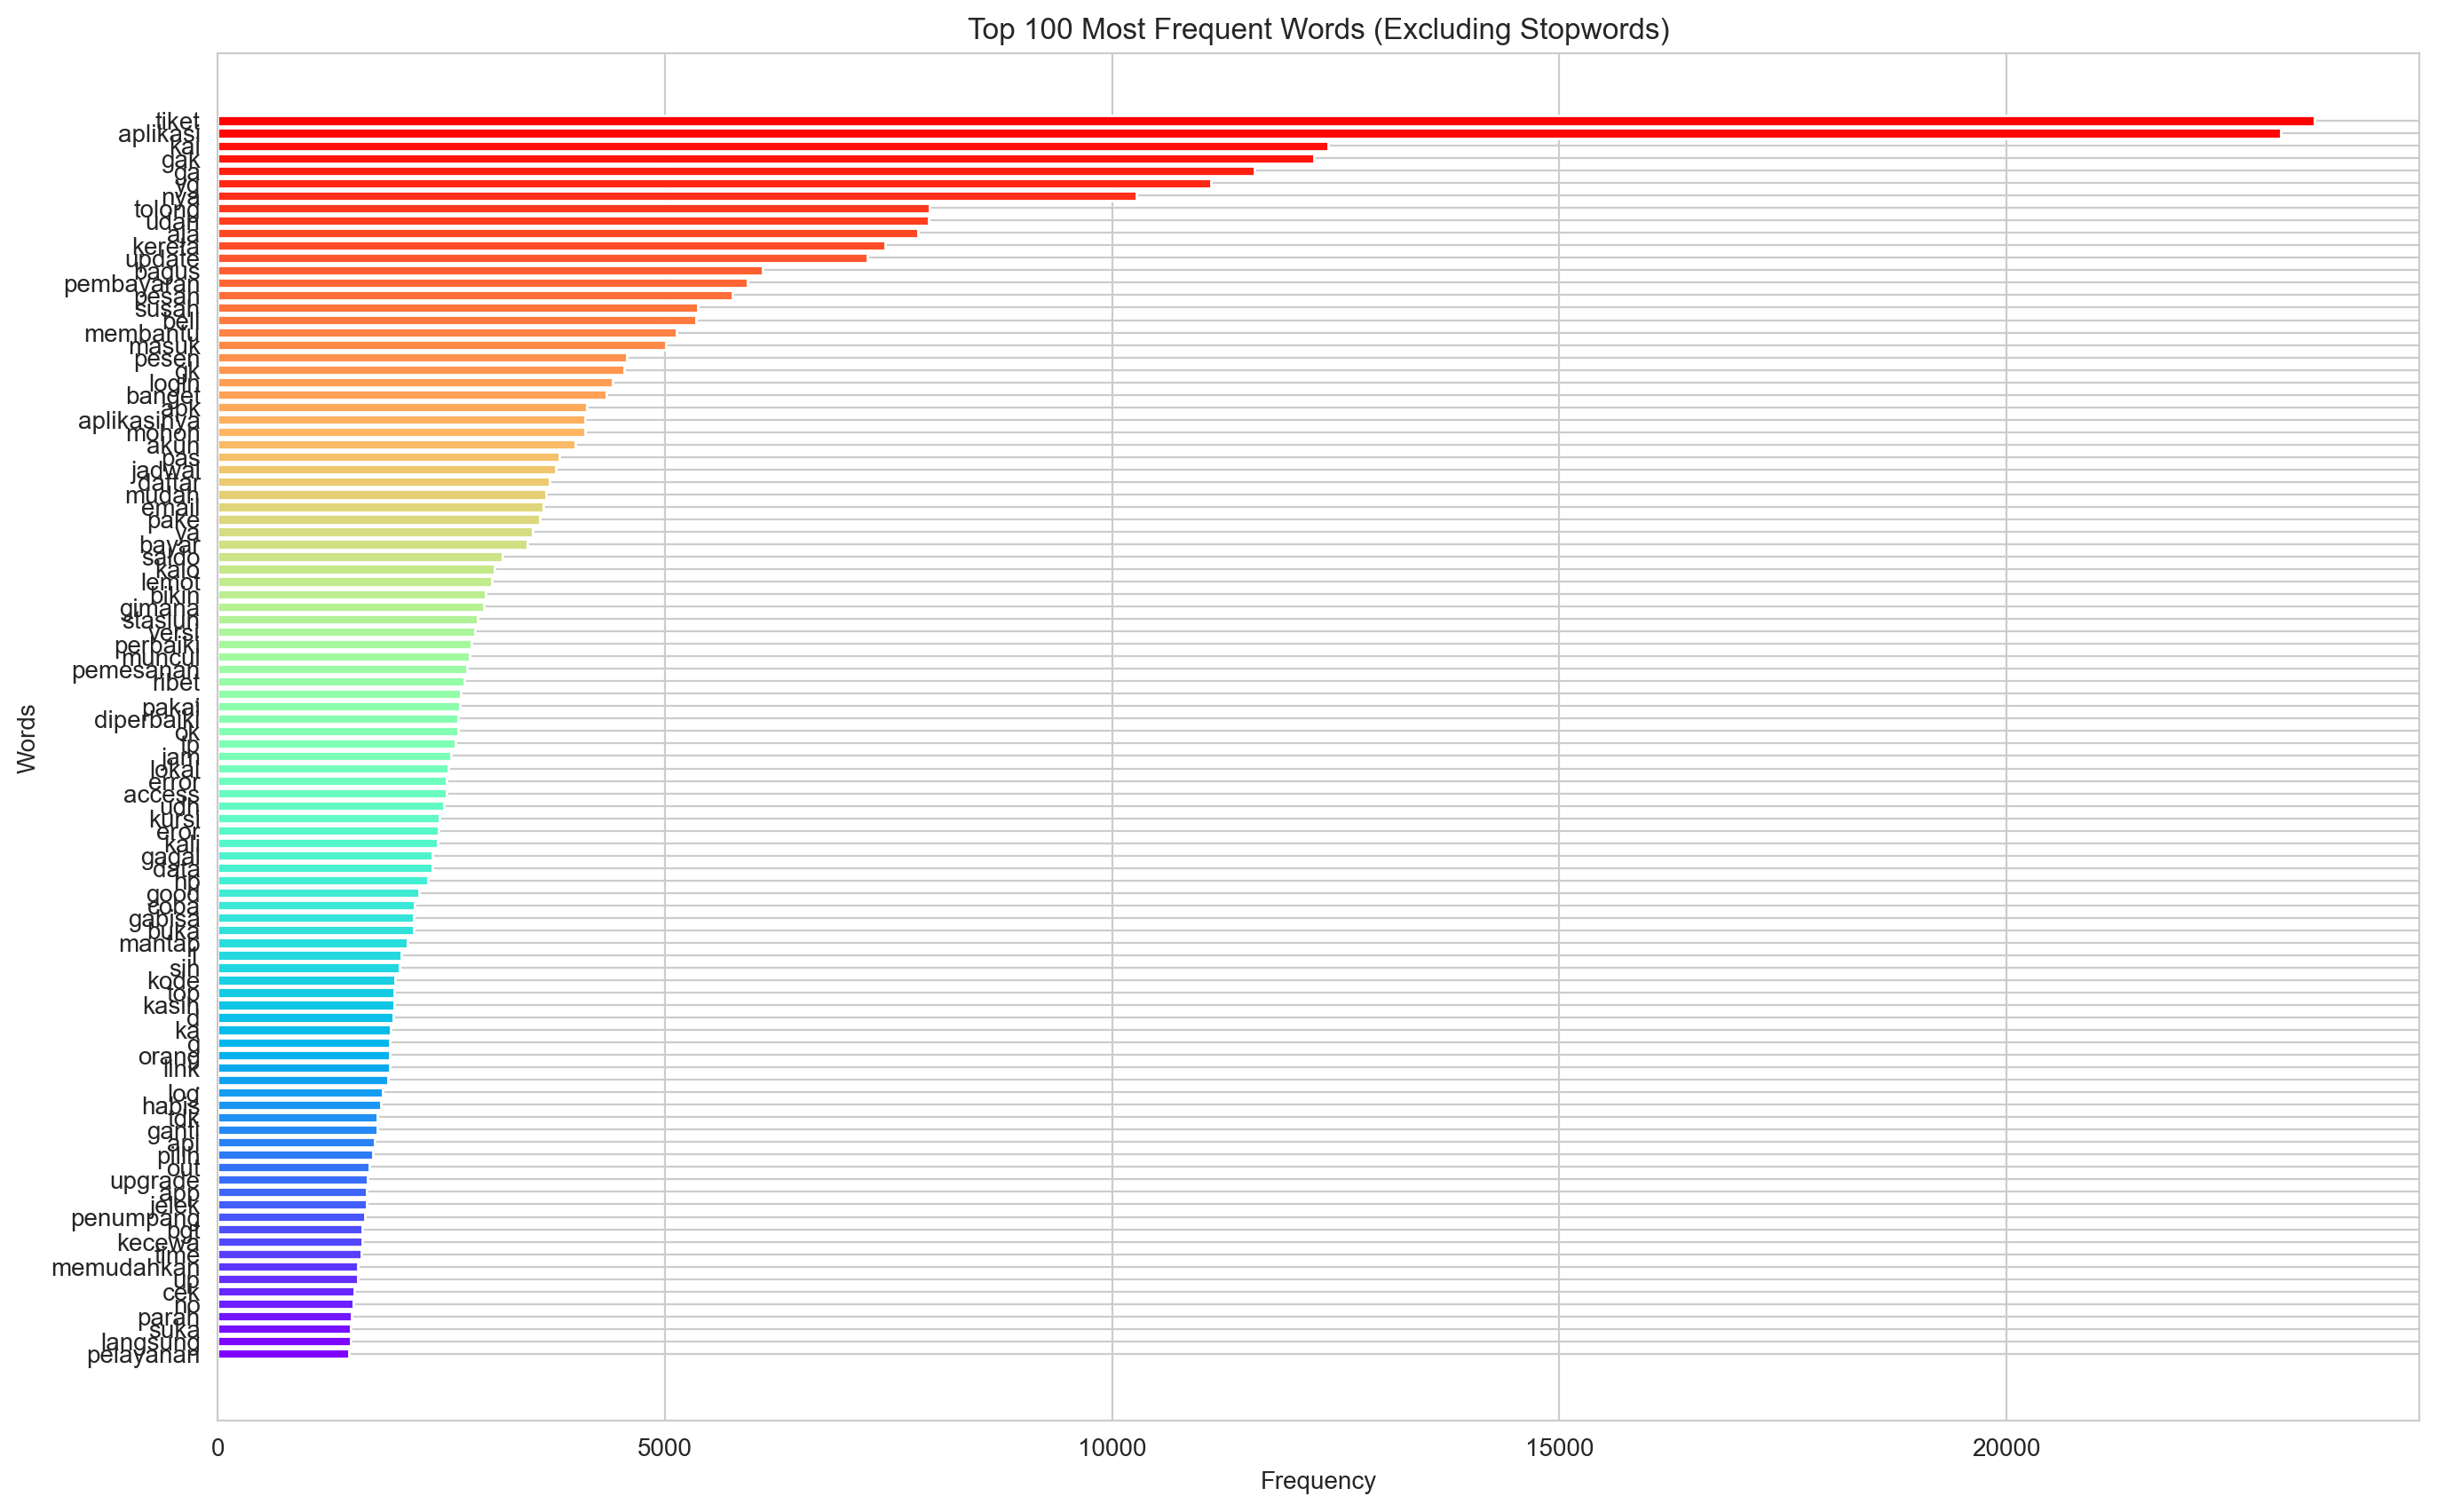

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from collections import Counter

# Assuming the text column is named 'content'
text_column = 'content'

# Combine all text data into one string
all_text = ' '.join(df_kai[text_column].dropna().astype(str))

# Tokenize words and remove stopwords
words = all_text.split()
filtered_words = [word.lower() for word in words if word.lower() not in indonesian_stopwords]

# Count frequent words
word_counts = Counter(filtered_words)
common_words = word_counts.most_common(100)

# Convert to DataFrame for better visualization
word_freq_df = pd.DataFrame(common_words, columns=['Word', 'Frequency'])

# Display the most common words
display(word_freq_df)

# Plot the frequent words with rainbow colormap (horizontal barplot)
plt.figure(figsize=(16, 10))

# generate warna rainbow sesuai jumlah kata
colors = plt.cm.rainbow(np.linspace(0, 1, len(word_freq_df)))

# plot horizontal bar
bars = plt.barh(
    word_freq_df['Word'][::-1],
    word_freq_df['Frequency'][::-1],
    color=colors
)

plt.xlabel("Frequency")
plt.ylabel("Words")
plt.title("Top 100 Most Frequent Words (Excluding Stopwords)")
plt.show()

In [21]:

common_words

[('tiket', 23443),
 ('aplikasi', 23065),
 ('kai', 12418),
 ('gak', 12256),
 ('ga', 11595),
 ('yg', 11100),
 ('nya', 10271),
 ('tolong', 7960),
 ('udah', 7946),
 ('aja', 7833),
 ('kereta', 7459),
 ('update', 7268),
 ('bagus', 6093),
 ('pembayaran', 5922),
 ('pesan', 5755),
 ('susah', 5368),
 ('beli', 5348),
 ('membantu', 5132),
 ('masuk', 5015),
 ('pesen', 4570),
 ('gk', 4542),
 ('login', 4412),
 ('banget', 4344),
 ('apk', 4128),
 ('aplikasinya', 4107),
 ('mohon', 4107),
 ('akun', 3995),
 ('pas', 3816),
 ('jadwal', 3777),
 ('daftar', 3715),
 ('mudah', 3673),
 ('email', 3645),
 ('pake', 3597),
 ('ya', 3518),
 ('bayar', 3458),
 ('saldo', 3188),
 ('kalo', 3091),
 ('lemot', 3067),
 ('bikin', 2994),
 ('gimana', 2976),
 ('stasiun', 2902),
 ('versi', 2877),
 ('perbaiki', 2835),
 ('muncul', 2814),
 ('pemesanan', 2792),
 ('ribet', 2758),
 (',', 2713),
 ('pakai', 2703),
 ('diperbaiki', 2687),
 ('ok', 2685),
 ('tp', 2658),
 ('jam', 2608),
 ('lokal', 2582),
 ('error', 2562),
 ('access', 2557),
 ('u

In [22]:
# Pastikan indonesian_stopwords berbentuk set
indonesian_stopwords = set(indonesian_stopwords)

# Add custom stopwords dari hasil top 100 frequent words
custom_stopwords = {
    # filler umum
    "ga", "gak", "gk", "udah", "udh", "aja", "aja", "aja", "ya", "tp", "bgt", "ok", "gw", "sih",
    # kata ganti/partikel
    "nya", "yg", "kalo", "d", "in",
    # tanda baca/angka
    ",", ".", "1", "2",
    # umum tidak bermakna kontekstual
    "aja", "mulu", "udah", "udh", "sampe"
}


# Pastikan kata-kata penting tidak ikut jadi stopwords
for word in ["aplikasi", "apk", "app"]:
    indonesian_stopwords.discard(word)

# Merge with existing stopwords
indonesian_stopwords.update(custom_stopwords)

print("Updated stopwords:", sorted(indonesian_stopwords))

Updated stopwords: [',', '.', '1', '2', 'ada', 'adalah', 'adanya', 'adapun', 'agak', 'agaknya', 'agar', 'aja', 'akan', 'akankah', 'akhir', 'akhiri', 'akhirnya', 'aku', 'akulah', 'amat', 'amatlah', 'anda', 'andalah', 'antar', 'antara', 'antaranya', 'apa', 'apaan', 'apabila', 'apakah', 'apalagi', 'apatah', 'artinya', 'asal', 'asalkan', 'atas', 'atau', 'ataukah', 'ataupun', 'awal', 'awalnya', 'bagai', 'bagaikan', 'bagaimana', 'bagaimanakah', 'bagaimanapun', 'bagi', 'bagian', 'bahkan', 'bahwa', 'bahwasanya', 'baik', 'bakal', 'bakalan', 'balik', 'banyak', 'bapak', 'baru', 'bawah', 'beberapa', 'begini', 'beginian', 'beginikah', 'beginilah', 'begitu', 'begitukah', 'begitulah', 'begitupun', 'bekerja', 'belakang', 'belakangan', 'belum', 'belumlah', 'benar', 'benarkah', 'benarlah', 'berada', 'berakhir', 'berakhirlah', 'berakhirnya', 'berapa', 'berapakah', 'berapalah', 'berapapun', 'berarti', 'berawal', 'berbagai', 'berdatangan', 'beri', 'berikan', 'berikut', 'berikutnya', 'berjumlah', 'berkali-k

Stopwords x Tokenization

🔎 Words removed by custom stopwords:


,Word,Frequency
0,di,26792
1,bisa,26487
2,tidak,17149
3,saya,16996
4,dan,16755
...,...,...
620,bolehlah,1
621,perlukah,1
622,sajalah,1
623,seluruhnya,1


,Word,Frequency
0,tiket,23443
1,aplikasi,23065
2,kai,12418
3,tolong,7960
4,kereta,7459
...,...,...
95,semoga,1333
96,acces,1329
97,loading,1313
98,cepat,1303


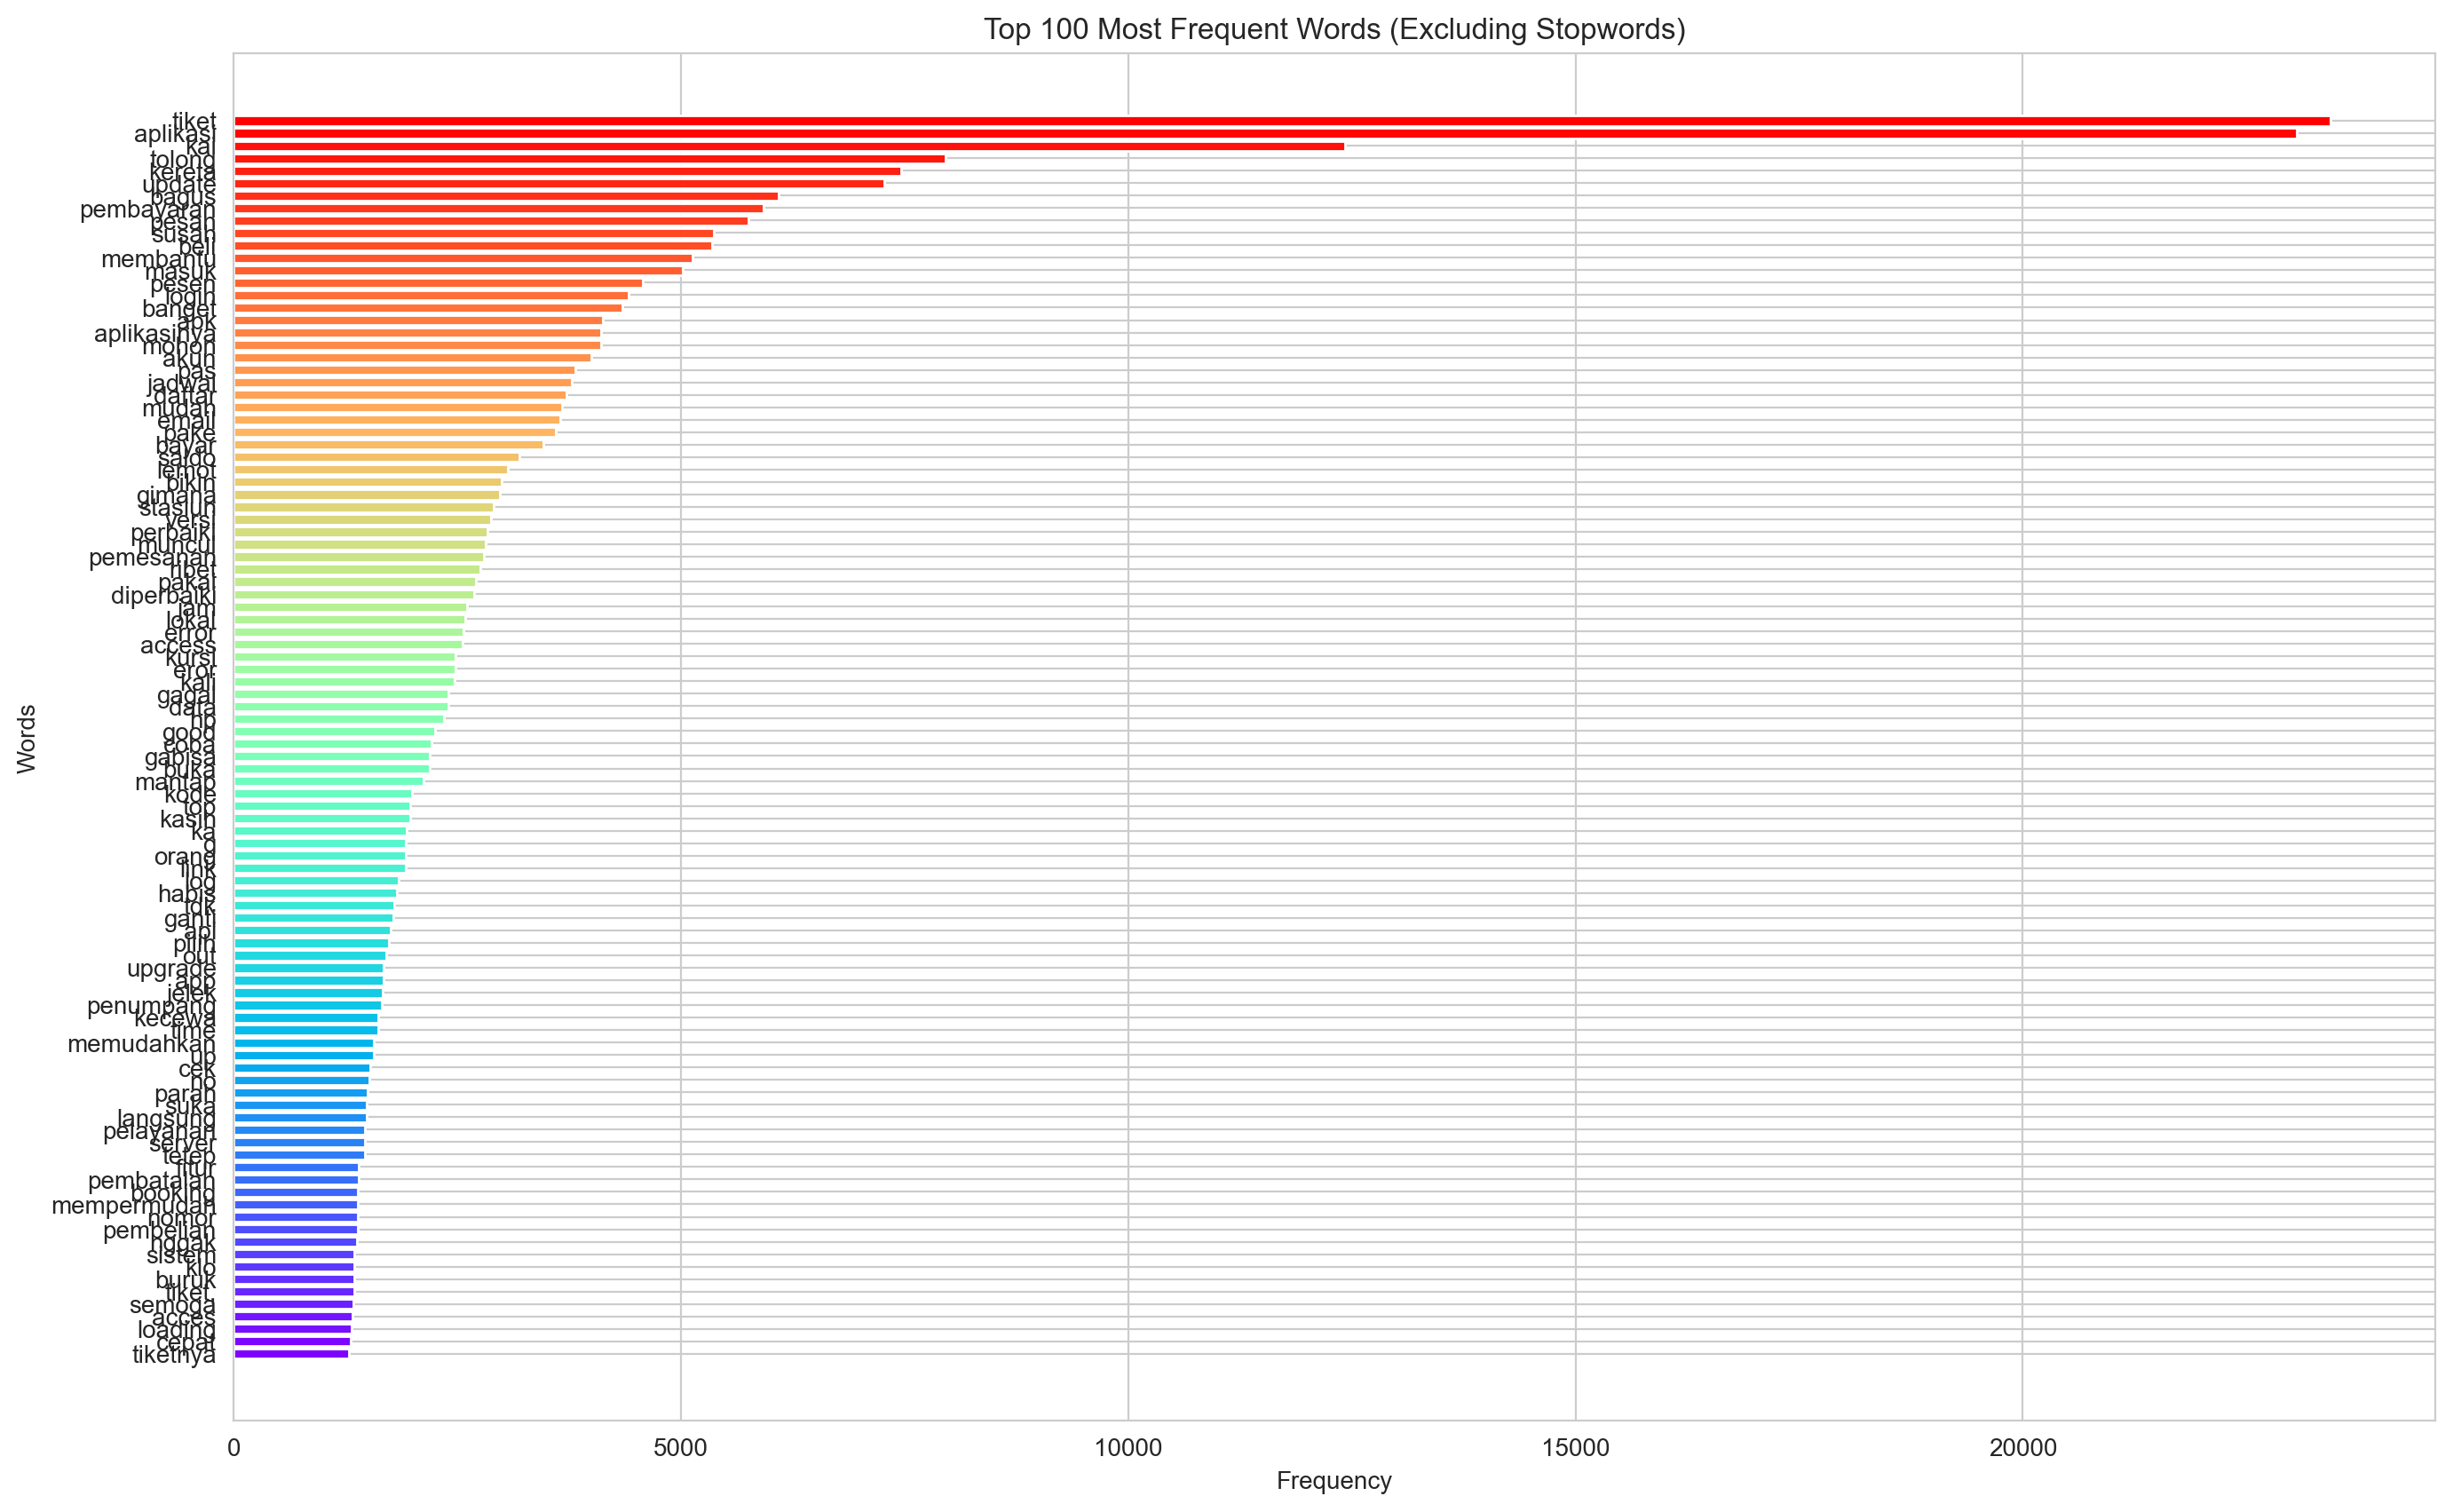

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from collections import Counter

# Assuming the text column is named 'content'
text_column = 'content'

# Combine all text data into one string
all_text = ' '.join(df_kai[text_column].dropna().astype(str))

# Tokenize words
words = [word.lower() for word in all_text.split()]

# Cari kata yang kehapus karena stopwords
removed_words = [word for word in words if word in indonesian_stopwords]

# Hitung frekuensi kata yang kehapus
removed_counts = Counter(removed_words)
removed_df = pd.DataFrame(removed_counts.most_common(), columns=['Word', 'Frequency'])

print("🔎 Words removed by custom stopwords:")
display(removed_df)

# Filter stopwords
filtered_words = [word for word in words if word not in indonesian_stopwords]

# Count frequent words
word_counts = Counter(filtered_words)
common_words = word_counts.most_common(100)

# Convert to DataFrame for better visualization
word_freq_df = pd.DataFrame(common_words, columns=['Word', 'Frequency'])

# Display the most common words
display(word_freq_df)

# Plot the frequent words with rainbow colormap (horizontal barplot)
plt.figure(figsize=(16, 10))

# generate warna rainbow sesuai jumlah kata
colors = plt.cm.rainbow(np.linspace(0, 1, len(word_freq_df)))

# plot horizontal bar
bars = plt.barh(
    word_freq_df['Word'][::-1],
    word_freq_df['Frequency'][::-1],
    color=colors
)

plt.xlabel("Frequency")
plt.ylabel("Words")
plt.title("Top 100 Most Frequent Words (Excluding Stopwords)")
plt.show()

In [25]:

# fungsi untuk hapus stopwords
def remove_stopwords(text):
    if isinstance(text, str):
        words = text.lower().split()
        return ' '.join([w for w in words if w not in indonesian_stopwords])
    return text

# bikin kolom baru di dataframe
df_kai['clean_content'] = df_kai['content'].apply(remove_stopwords)

# cek hasil
print(df_kai[['content', 'clean_content']].head(10))

                                             content  \
0  untuk top up lama banget tolong dong diperbaik...   
1                                           jwuebege   
2  aplikasi tolol. kode otp lama.bikin pasword gk...   
3                                             good 👍   
4  setiap top up terpotong 3rban lama nunggu 15mn...   
5                                      malang jember   
6                                         oke mantap   
7                                    mudah dan cepat   
8  hampir tiap kali mau buka aplikasi mesti di up...   
9  alhamdulillah dengan kai access pp karawang ja...   

                                       clean_content  
0  top up banget tolong diperbaiki biar ketinggal...  
1                                           jwuebege  
2  aplikasi tolol. kode otp lama.bikin pasword bi...  
3                                             good 👍  
4  top up terpotong 3rban nunggu 15mnt, riwayat t...  
5                                      malang jember 

In [26]:
df_kai['clean_tokens'] = df_kai['tokens'].apply(
    lambda toks: [w for w in toks if w not in indonesian_stopwords]
)

In [27]:
# Liat 5 baris pertama
print(df_kai[['content', 'tokens', 'clean_tokens']].head())

# Liat baris tertentu (misal index ke-100)
print(df_kai[['content', 'tokens', 'clean_tokens']].iloc[100])

# Kalau mau tampil rapi (pake Pandas display)
import pandas as pd
pd.set_option('max_colwidth', 200)  # biar teksnya ga dipotong
display(df_kai[['content', 'tokens', 'clean_tokens']].sample(5))

                                             content  \
0  untuk top up lama banget tolong dong diperbaik...   
1                                           jwuebege   
2  aplikasi tolol. kode otp lama.bikin pasword gk...   
3                                             good 👍   
4  setiap top up terpotong 3rban lama nunggu 15mn...   

                                              tokens  \
0  [untuk, top, up, lama, banget, tolong, dong, d...   
1                                         [jwuebege]   
2  [aplikasi, tolol, ., kode, otp, lama.bikin, pa...   
3                                          [good, 👍]   
4  [setiap, top, up, terpotong, 3rban, lama, nung...   

                                        clean_tokens  
0  [top, up, banget, tolong, diperbaiki, biar, ke...  
1                                         [jwuebege]  
2  [aplikasi, tolol, kode, otp, lama.bikin, paswo...  
3                                          [good, 👍]  
4  [top, up, terpotong, 3rban, nunggu, 15mnt, riw..

,content,tokens,clean_tokens
76330,"sering ada gangguan. sdah pesan tiket, dan dibayar, tapi di aplikasi tiket tidak muncul. klo diupdate suruh login ulang trus pasword salah, pdahal memang pasword nya itu. sdah di reset pasword tet...","[sering, ada, gangguan, ., sdah, pesan, tiket, ,, dan, dibayar, ,, tapi, di, aplikasi, tiket, tidak, muncul, ., klo, diupdate, suruh, login, ulang, trus, pasword, salah, ,, pdahal, memang, pasword...","[gangguan, sdah, pesan, tiket, dibayar, aplikasi, tiket, muncul, klo, diupdate, suruh, login, ulang, trus, pasword, salah, pdahal, pasword, sdah, reset, pasword, tetep, g, menghubungi, contact, ce..."
99976,"situs yg gak jelas!!! jaringan penuh diblg periksa koneksi anda,bujanglah \nbahhhh!!!","[situs, yg, gak, jelas, !, !, !, jaringan, penuh, diblg, periksa, koneksi, anda, ,, bujanglah, bahhhh, !, !, !]","[situs, !, !, !, jaringan, penuh, diblg, periksa, koneksi, bujanglah, bahhhh, !, !, !]"
104774,good,[good],[good]
36454,"apalikasinya mudah logout sendiri, menyusahkan","[apalikasinya, mudah, logout, sendiri, ,, menyusahkan]","[apalikasinya, mudah, logout, menyusahkan]"
6573,"pengen bikin akun basic aja dipersulit.....ini niat bikin aplikasi gak sih , dasar gak jelas 😡👎","[pengen, bikin, akun, basic, aja, dipersulit, ....., ini, niat, bikin, aplikasi, gak, sih, ,, dasar, gak, jelas, 😡👎]","[pengen, bikin, akun, basic, dipersulit, ....., niat, bikin, aplikasi, dasar, 😡👎]"


Stemmer

In [28]:
!pip install sastrawi


[notice] A new release of pip is available: 25.0.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [29]:
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

# Inisialisasi stemmer
factory = StemmerFactory()
stemmer = factory.create_stemmer()

# Apply stemming ke clean_tokens
df_kai['stemmed_tokens'] = df_kai['clean_tokens'].apply(
    lambda toks: [stemmer.stem(w) for w in toks]
)

# Kalau mau bikin string lagi (buat TF-IDF atau ML klasik)
df_kai['final_text'] = df_kai['stemmed_tokens'].apply(lambda x: ' '.join(x))

# Cek hasil
print(df_kai[['content', 'clean_tokens', 'stemmed_tokens', 'final_text']].head())

                                                                                                                                                                                                   content  \
0  untuk top up lama banget tolong dong diperbaiki biar ga ketinggalan kereta apalagi keaadan urgent. itu aja sih nanti kalo sudah diperbaiki untuk kecepatan top upnya saya ubah lagi ratingnya, terim...   
1                                                                                                                                                                                                 jwuebege   
2                                                                                                aplikasi tolol. kode otp lama.bikin pasword gk bisa!!!! bantu rate bintang 1 aplikasi bkin naik darah!!!!   
3                                                                                                                                                                               

In [30]:
# Kolom penting dari review
important_cols = ["content", "score", "thumbsUpCount",
                  "reviewCreatedVersion", "at",
                  "replyContent", "repliedAt"]

# Kolom hasil preprocessing
preproc_cols = ["tokens", "clean_tokens", "stemmed_tokens", "final_text"]

# Gabung jadi satu
df_preview = df_kai.loc[:, important_cols + preproc_cols]

# Biar teks ga kepotong
import pandas as pd
pd.set_option('max_colwidth', 150)

# Tampilkan sample 5 row
display(df_preview.sample(5))

,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,tokens,clean_tokens,stemmed_tokens,final_text
48718,helo kai kenapa skrg pembayaran qris nya gaada sih.. pdhl waktu itu ada. harusnya untuk pembayaran semua eqomers bisa.. biar tdk merepotkan,4,0,5.0.5,2022-11-19 09:17:56,None,NaT,"[helo, kai, kenapa, skrg, pembayaran, qris, nya, gaada, sih, .., pdhl, waktu, itu, ada, ., harusnya, untuk, pembayaran, semua, eqomers, bisa, .., ...","[helo, kai, skrg, pembayaran, qris, gaada, .., pdhl, pembayaran, eqomers, .., biar, tdk, merepotkan]","[helo, kai, skrg, bayar, qris, gaada, , pdhl, bayar, eqomers, , biar, tdk, repot]",helo kai skrg bayar qris gaada pdhl bayar eqomers biar tdk repot
108646,mantap,5,0,1.0.1.1,2015-03-06 05:22:02,None,NaT,[mantap],[mantap],[mantap],mantap
23543,"saya sudah top up ""kai pay"" untuk pemesanan tiket, tiket sudah saya pesan saldo nya pun sudah terpotong. eh malah ada pemberitahuan selesaikan pem...",1,3,6.4.1,2024-04-17 06:34:57,None,NaT,"[saya, sudah, top, up, ``, kai, pay, '', untuk, pemesanan, tiket, ,, tiket, sudah, saya, pesan, saldo, nya, pun, sudah, terpotong, ., eh, malah, a...","[top, up, ``, kai, pay, '', pemesanan, tiket, tiket, pesan, saldo, terpotong, eh, pemberitahuan, selesaikan, pembayaran, gimana, ceritanya, saldo,...","[top, up, , kai, pay, , mesan, tiket, tiket, pesan, saldo, potong, eh, pemberitahuan, selesai, bayar, gimana, cerita, saldo, potong, , tunggu, bay...",top up kai pay mesan tiket tiket pesan saldo potong eh pemberitahuan selesai bayar gimana cerita saldo potong tunggu bayar alhasil tiket batal...
60403,aplikasi bagus buat pesen tiket kereta api,5,0,4.4.7,2021-05-27 09:33:48,None,NaT,"[aplikasi, bagus, buat, pesen, tiket, kereta, api]","[aplikasi, bagus, pesen, tiket, kereta, api]","[aplikasi, bagus, sen, tiket, kereta, api]",aplikasi bagus sen tiket kereta api
50888,"kenapa qris selalu lemot padaal sinyal buat ig, semuanya aman, cuman kai yang error, mohon diperbaiki lagi",1,0,5.0.1,2022-08-08 21:42:21,None,NaT,"[kenapa, qris, selalu, lemot, padaal, sinyal, buat, ig, ,, semuanya, aman, ,, cuman, kai, yang, error, ,, mohon, diperbaiki, lagi]","[qris, lemot, padaal, sinyal, ig, aman, cuman, kai, error, mohon, diperbaiki]","[qris, lot, padaal, sinyal, ig, aman, cuman, kai, error, mohon, baik]",qris lot padaal sinyal ig aman cuman kai error mohon baik


Clean Dataset

In [31]:
# CLEAN data (lengkap dengan preprocessing)
df_kai_clean = df_kai.loc[:, [
    "content", "score", "thumbsUpCount", "reviewCreatedVersion", "at",
    "replyContent", "repliedAt", "tokens", "clean_tokens", "stemmed_tokens", "final_text"
]]
df_kai_clean.to_csv("df_kai_clean.csv", index=False)


Sentiment Polarity

In [32]:
#Creating polarity on the column: content (review from the apps) using TextBlob
#Read https://textblob.readthedocs.io/en/dev/quickstart.html

from textblob import TextBlob
# Handle None values in 'content' column by replacing them with empty strings
df_kai['sentiment_polarity'] = df_kai['content'].astype(str).apply(lambda x: TextBlob(x).polarity)
df_kai['sentiment_subjective'] = df_kai['content'].astype(str).apply(lambda x: TextBlob(x).subjectivity)

In [33]:

df_kai.loc[:,["content","score","sentiment_polarity", "sentiment_subjective"]]

,content,score,sentiment_polarity,sentiment_subjective
0,untuk top up lama banget tolong dong diperbaiki biar ga ketinggalan kereta apalagi keaadan urgent. itu aja sih nanti kalo sudah diperbaiki untuk k...,1,0.500,0.50
1,jwuebege,5,0.000,0.00
2,aplikasi tolol. kode otp lama.bikin pasword gk bisa!!!! bantu rate bintang 1 aplikasi bkin naik darah!!!!,1,0.000,0.00
3,good 👍,5,0.700,0.60
4,"setiap top up terpotong 3rban lama nunggu 15mnt, riwayat transaksi topup atau pemakaian gabisa diliat muncul error code format exception time not ...",4,0.275,0.45
...,...,...,...,...
109177,good,5,0.700,0.60
109178,keren,5,0.000,0.00
109179,semoga segera di fix kan gangguan bug di app,5,0.000,0.00
109180,sangat membantu,4,0.000,0.00


In [34]:
#Add a column name polarity_rating from changing the score of the review into 3 labels: Pos, Negative Neutral
df_kai['sentiment_rating'] = df_kai['score'].apply(lambda x: 'Positive' if x > 3 else('Neutral' if x == 3  else 'Negative'))
df_kai.loc[:,["content","score","sentiment_polarity", "sentiment_subjective","sentiment_rating"]]

,content,score,sentiment_polarity,sentiment_subjective,sentiment_rating
0,untuk top up lama banget tolong dong diperbaiki biar ga ketinggalan kereta apalagi keaadan urgent. itu aja sih nanti kalo sudah diperbaiki untuk k...,1,0.500,0.50,Negative
1,jwuebege,5,0.000,0.00,Positive
2,aplikasi tolol. kode otp lama.bikin pasword gk bisa!!!! bantu rate bintang 1 aplikasi bkin naik darah!!!!,1,0.000,0.00,Negative
3,good 👍,5,0.700,0.60,Positive
4,"setiap top up terpotong 3rban lama nunggu 15mnt, riwayat transaksi topup atau pemakaian gabisa diliat muncul error code format exception time not ...",4,0.275,0.45,Positive
...,...,...,...,...,...
109177,good,5,0.700,0.60,Positive
109178,keren,5,0.000,0.00,Positive
109179,semoga segera di fix kan gangguan bug di app,5,0.000,0.00,Positive
109180,sangat membantu,4,0.000,0.00,Positive


In [35]:

# Hitung jumlah tiap kategori sentiment
sentiment_counts = df_kai['sentiment_rating'].value_counts()
print(sentiment_counts)

# Kalau mau dalam bentuk persentase juga bisa:
sentiment_percentage = df_kai['sentiment_rating'].value_counts(normalize=True) * 100
print(sentiment_percentage)
     

sentiment_rating
Negative    60026
Positive    41906
Neutral      7250
Name: count, dtype: int64
sentiment_rating
Negative    54.977927
Positive    38.381785
Neutral      6.640289
Name: proportion, dtype: float64


In [36]:
# Tampilkan hanya kolom content dan sentiment_rating
df_view = df_kai.loc[:, ["content", "sentiment_rating"]]

# Contoh tampilkan semua
print(df_view.head())

# Kalau mau filter hanya review positif
df_positive = df_view[df_view['sentiment_rating'] == "Positive"]
print(df_positive.head())

# Kalau mau filter hanya review negatif
df_negative = df_view[df_view['sentiment_rating'] == "Negative"]
print(df_negative.head())

# Kalau mau filter hanya review netral
df_neutral = df_view[df_view['sentiment_rating'] == "Neutral"]
print(df_neutral.head())

                                                                                                                                                 content  \
0  untuk top up lama banget tolong dong diperbaiki biar ga ketinggalan kereta apalagi keaadan urgent. itu aja sih nanti kalo sudah diperbaiki untuk k...   
1                                                                                                                                               jwuebege   
2                                              aplikasi tolol. kode otp lama.bikin pasword gk bisa!!!! bantu rate bintang 1 aplikasi bkin naik darah!!!!   
3                                                                                                                                                 good 👍   
4  setiap top up terpotong 3rban lama nunggu 15mnt, riwayat transaksi topup atau pemakaian gabisa diliat muncul error code format exception time not ...   

  sentiment_rating  
0         Negative  
1         Positive  


Bag of Words

In [37]:
# Ambil 50 positif
pos_sample = df_kai[df_kai['sentiment_rating'] == 'Positive'].sample(n=50, random_state=42)

# Ambil 50 negatif
neg_sample = df_kai[df_kai['sentiment_rating'] == 'Negative'].sample(n=50, random_state=42)

# Gabung jadi satu dataset balanced
balanced_df = pd.concat([pos_sample, neg_sample])

# Reset index biar rapi
balanced_df = balanced_df.reset_index(drop=True)

# Cek hasil, bakal keliatan content & final_text masih nyambung
print(balanced_df[['content', 'final_text', 'sentiment_rating']].head())

                                         content  \
0                                         mantap   
1         gimana ini kok kode aktifnya gk kenak²   
2                                         ok sip   
3  terima kasih memudahkan dalam pembelian tiket   
4                                          great   

                      final_text sentiment_rating  
0                         mantap         Positive  
1          gimana kode aktif nak         Positive  
2                            sip         Positive  
3  terima kasih mudah beli tiket         Positive  
4                          great         Positive  


In [38]:
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd

# Asumsinya balanced_df sudah ada (isi 50 Positif + 50 Negatif)
# Kalau mau langsung dari df_jlingko juga bisa, tinggal ganti variabelnya

# Inisialisasi BoW
vectorizer = CountVectorizer()

# Fit dan transform ke final_text
X_bow = vectorizer.fit_transform(balanced_df['final_text'])

# Konversi ke DataFrame biar enak dilihat
bow_df = pd.DataFrame(
    X_bow.toarray(),
    columns=vectorizer.get_feature_names_out()
)

# Gabungkan dengan label biar jelas
bow_df = pd.concat([balanced_df[['content', 'final_text', 'sentiment_rating']], bow_df], axis=1)

# Cek hasil
print(bow_df.head())

                                         content  \
0                                         mantap   
1         gimana ini kok kode aktifnya gk kenak²   
2                                         ok sip   
3  terima kasih memudahkan dalam pembelian tiket   
4                                          great   

                      final_text sentiment_rating  15  2024  22  abis  acces  \
0                         mantap         Positive   0     0   0     0      0   
1          gimana kode aktif nak         Positive   0     0   0     0      0   
2                            sip         Positive   0     0   0     0      0   
3  terima kasih mudah beli tiket         Positive   0     0   0     0      0   
4                          great         Positive   0     0   0     0      0   

   access  admin  ...  upaya  update  upgrade  urgent  utk  verifikasi  war  \
0       0      0  ...      0       0        0       0    0           0    0   
1       0      0  ...      0       0        0   

Analisis Deskriptif

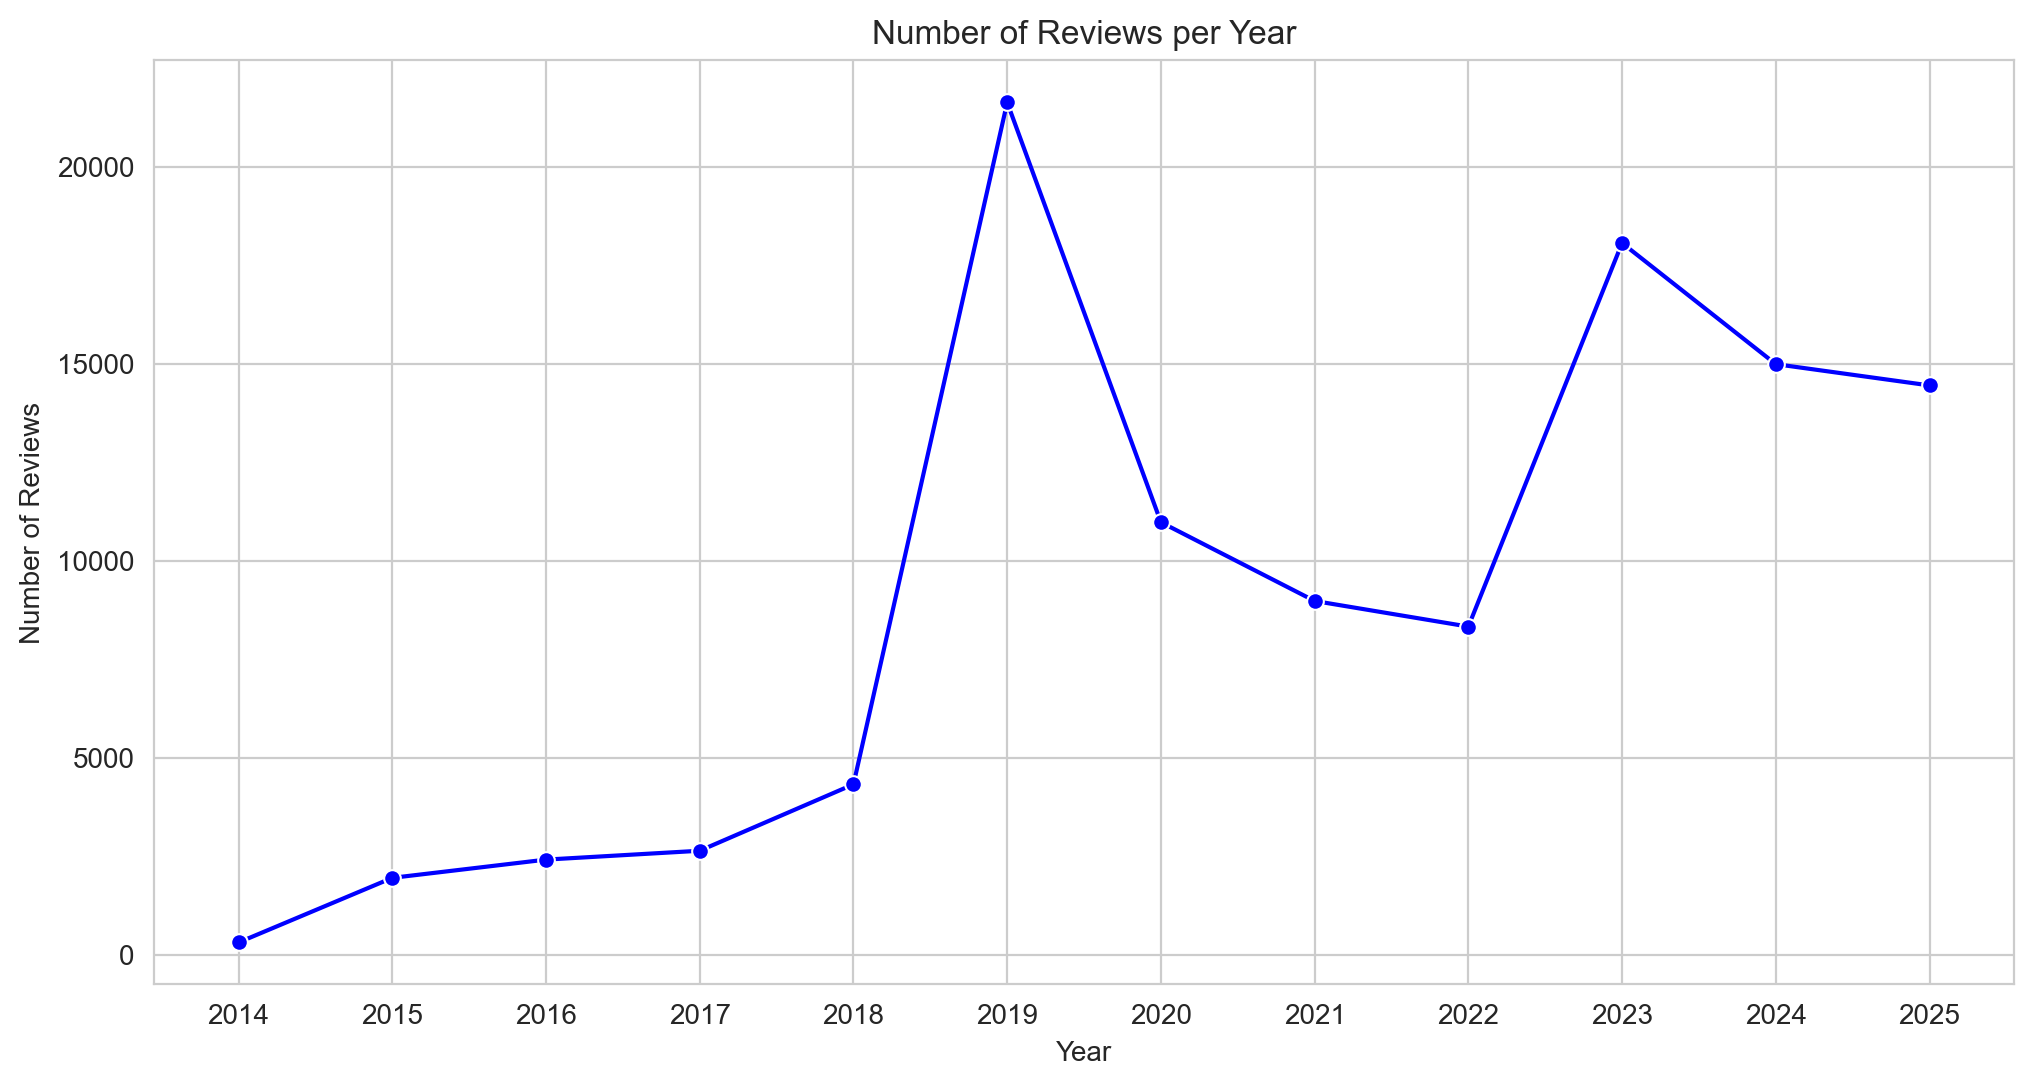

In [39]:
# Pastikan 'year' integer
df_kai['year'] = df_kai['at'].dt.year.astype(int)

# Hitung jumlah review per tahun
year_counts = df_kai['year'].value_counts().sort_index()

# Convert index jadi int juga
year_counts.index = year_counts.index.astype(int)

#plot
plt.figure(figsize=(12, 6))
sns.lineplot(x=year_counts.index, y=year_counts.values, marker='o', color='blue')
plt.title('Number of Reviews per Year')
plt.xlabel('Year')
plt.ylabel('Number of Reviews')
plt.grid(True)

# Paksa sumbu X integer (tahun)
plt.xticks(year_counts.index)
plt.show()

     

REVIEW SCORE PER YEAR

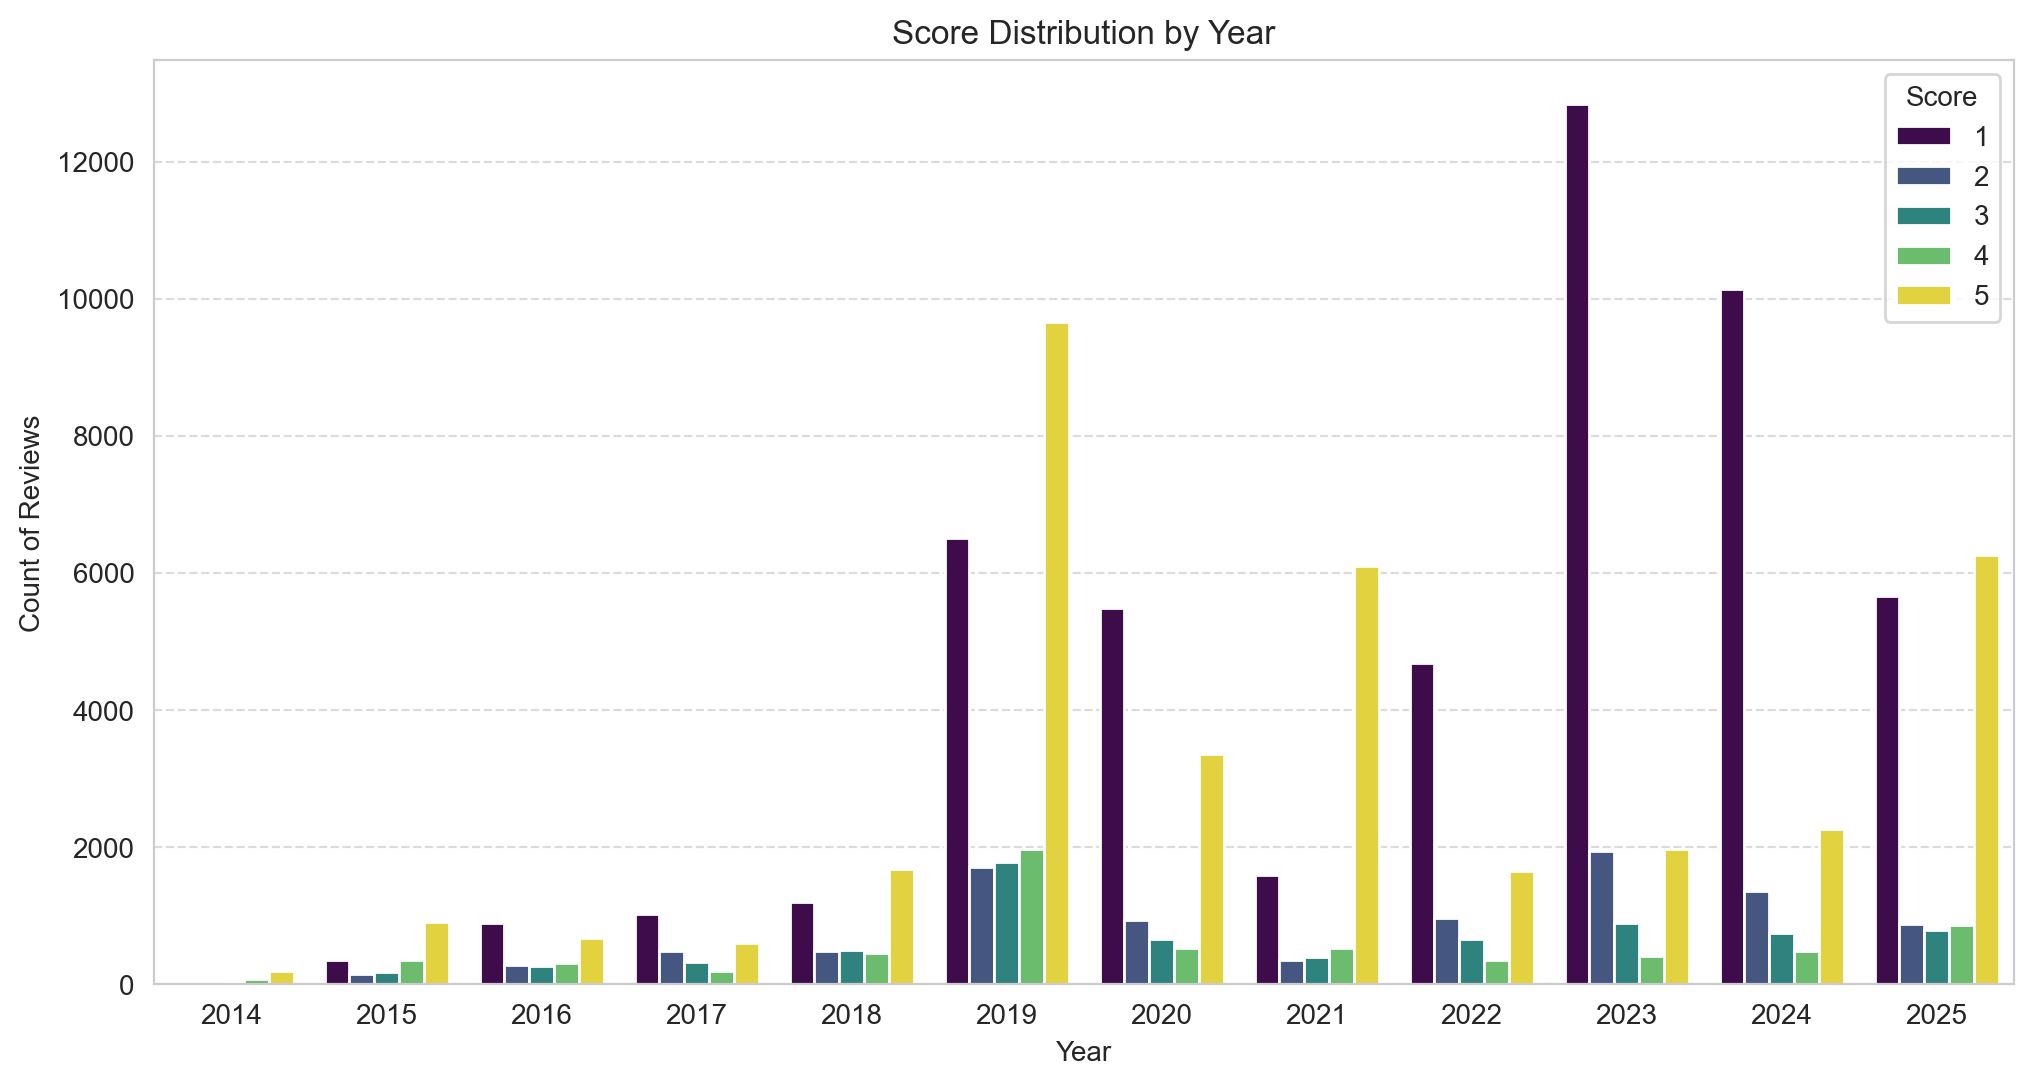

In [40]:

#Perbandingan skor review setiap tahun
plt.figure(figsize=(12, 6))
sns.countplot(x='year', hue='score', data=df_kai, palette='viridis')

plt.title('Score Distribution by Year')
plt.xlabel('Year')
plt.ylabel('Count of Reviews')
plt.legend(title='Score')
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.show()
     

Review Sentiment Word Cloud

In [46]:
!pip install wordcloud



[notice] A new release of pip is available: 25.0.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


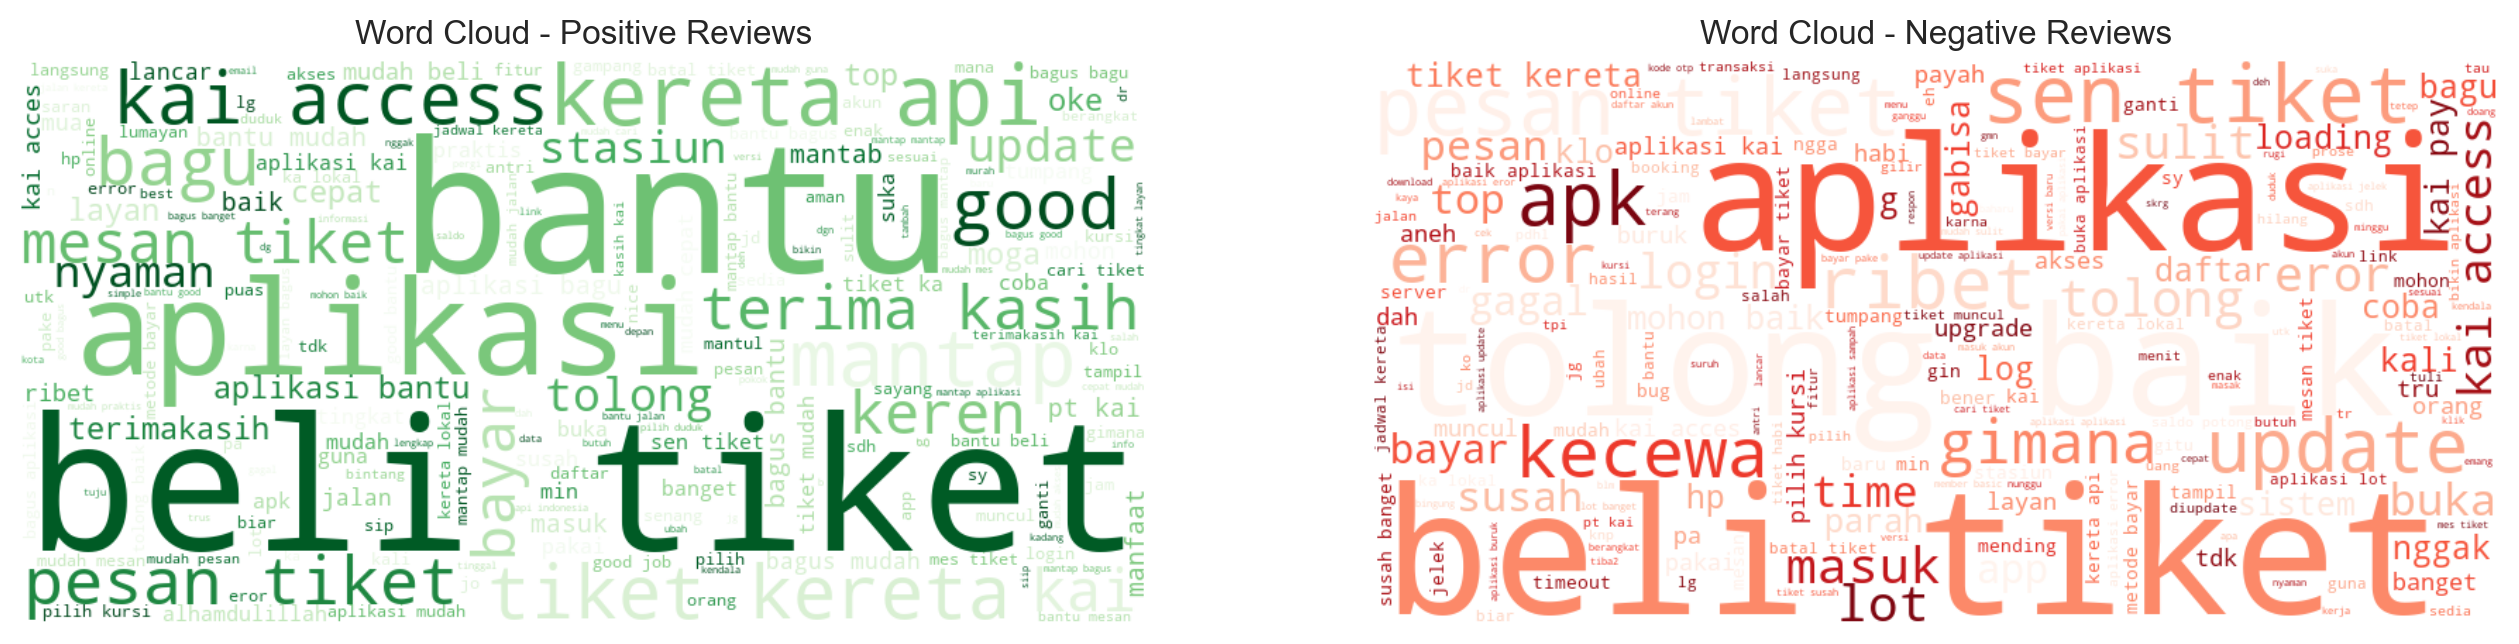

In [49]:
from wordcloud import WordCloud

# Pisahkan review positif dan negatif
positive_text = " ".join(df_kai[df_kai['sentiment_rating'] == 'Positive']['final_text'])
negative_text = " ".join(df_kai[df_kai['sentiment_rating'] == 'Negative']['final_text'])

# Generate word cloud positif
wordcloud_pos = WordCloud(width=800, height=400, background_color='white', colormap='Greens').generate(positive_text)

# Generate word cloud negatif
wordcloud_neg = WordCloud(width=800, height=400, background_color='white', colormap='Reds').generate(negative_text)

# Plot keduanya
plt.figure(figsize=(16, 8))

plt.subplot(1, 2, 1)
plt.imshow(wordcloud_pos, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud - Positive Reviews')

plt.subplot(1, 2, 2)
plt.imshow(wordcloud_neg, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud - Negative Reviews')

plt.show()